## 📚 Índice do Notebook

1. [🛠️ Correção de Viés para Projeções Futuras](#-correção-de-viés-para-projeções-futuras)
    - [🟦 DBC Percentílico (Delta Bias Correction Percentílico)](#-dbc)
    - [🟩 Quantile Mapping (Mapeamento de Quantis)](#-quantile-mapping)
    - [🟥 EQM Downscaling (Empirical Quantile Mapping com Downscaling)](#-eqm)

# 🌍 Automatic IDF Graphs – Geração de Curvas IDF Históricas

Este notebook demonstra o processo de construção de curvas Intensidade-Duração-Frequência (IDF) a partir de dados históricos de precipitação.

🎯 O passo fundamental é a extração das séries de máximos anuais para diversas durações, que servirão de base para o ajuste estatístico e a geração da curva final.

<br>

## 🛠️ O que este notebook faz?

Neste notebook, vamos:

- 🛰️ Explicar a importância da correção de viés em projeções de modelos climáticos (GCMs).
- ⚙️ Aplicar e comparar três métodos de correção de viés: DBC, Quantile Mapping e EQM Downscaling.
- 🌍 Ajustar os dados de projeção futura (CLIMBra) com base nos dados observados (INMET).
- ✅ Visualizar os resultados de cada método para avaliar a eficácia da correção.  

#### Continuaremos seguindo o passo a passo claro. Para isso, teremos que resgatar algumas funções do notebook anterior:

In [1]:
from idf_analysis.data.processing import read_csv

# Captando os dados
inmet_daily_df = read_csv(path='../results/inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante_daily.csv')
climbra_hist_df = read_csv(path='../results/CABra467/historical/1980-2013_daily.csv')
climbra_future_df = read_csv(path='../results/CABra467/ssp245/2015-2100_daily.csv')

---
## 🛠️ Correção de Viés para Projeções Futuras

Nesta seção, aplicaremos três métodos de correção de viés aos dados de projeção climática, com o objetivo de aproximar os dados simulados pelos modelos climáticos (GCMs) das observações reais.

### 🎯 Por que corrigir o viés?

Modelos climáticos frequentemente apresentam desvios sistemáticos em relação às observações. A correção de viés é essencial para:
- Aumentar a confiabilidade das projeções futuras
- Alinhar estatisticamente os dados simulados com os observados
- Reduzir erros em aplicações hidrológicas e climáticas

### ⚙️ Métodos Aplicados

<br>

#### 🟦 DBC Percentílico (Delta Bias Correction Percentílico)

Este método realiza a correção da distribuição dos dados projetados com base nos percentis da série observada.  
Ele **ajusta os dados futuros simulados preservando a variação relativa (delta)** entre os cenários histórico e futuro do GCM.

✅ Ideal quando se quer **manter a tendência do modelo** climático, mas corrigir o desvio estatístico em relação às observações.  
🔍 Recomendado para análises que envolvem **mudanças relativas nas chuvas** ao longo do tempo.


[OK] Série completa! Nenhum período faltando.

[OK] Série completa! Nenhum período faltando.


Período comum considerado: 01-01-1980 até 31-12-2013
[OK] Série completa! Nenhum período faltando.



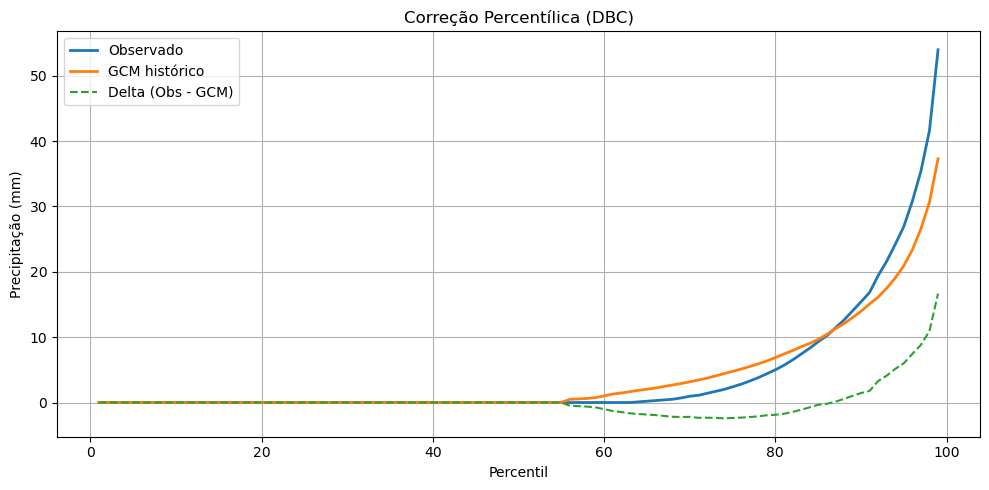


📊 DBC Percentilico - INMET Santana:


,Date,Precipitation Original,Precipitation
0,01-01-15,21.515111,27.884157
1,02-01-15,2.162179,0.266567
2,03-01-15,0.508390,0.000000
3,04-01-15,0.000000,0.000000
4,05-01-15,0.000000,0.000000
5,06-01-15,0.000000,0.000000
6,07-01-15,0.955343,0.000000
7,08-01-15,2.295300,0.330041
8,09-01-15,2.846442,0.640499
9,10-01-15,9.397092,8.880395


In [3]:
from idf_analysis.analysis.projection.dbc import dbc_percentilico

dbc_corrected_df = dbc_percentilico(
    name_obs='inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante',
    name_baseline='CABra467/historical/1980-2013',
    name_future='CABra467/ssp245/2015-2100',
    dir='../results',
    plot=True,
    save_csv_path='../results/inmet_daily_sao_paulo_mirante/inmet_sao_paulo_dbc.csv'
);

print("\n📊 DBC Percentilico - INMET Santana:")
display(dbc_corrected_df.head(10))

#### 🟩 Quantile Mapping (Mapeamento de Quantis)

Esse método mapeia os quantis dos dados simulados para os quantis dos dados observados, corrigindo a distribuição completa da variável.

✅ Corrige **toda a distribuição estatística** (não apenas média ou desvio), lidando bem com extremos.

🔍 Muito útil para aplicações que exigem boa representação dos **eventos extremos de precipitação**.

[OK] Série completa! Nenhum período faltando.

[OK] Série completa! Nenhum período faltando.


Período comum considerado: 01-01-1980 até 31-12-2013
[OK] Série completa! Nenhum período faltando.



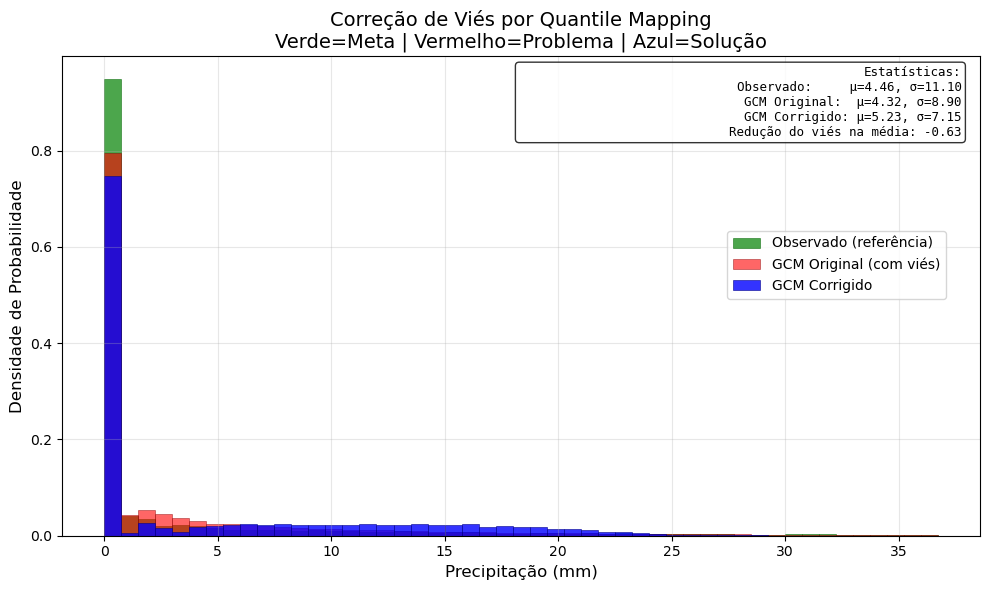


📊 Quantile Mapping - INMET Santana:


,Date,Precipitation Original,Precipitation
0,01-01-15,21.515111,19.582266
1,02-01-15,2.162179,6.418486
2,03-01-15,0.508390,1.454428
3,04-01-15,0.000000,0.000000
4,05-01-15,0.000000,0.000000
5,06-01-15,0.000000,0.000000
6,07-01-15,0.955343,3.194842
7,08-01-15,2.295300,6.695024
8,09-01-15,2.846442,7.732147
9,10-01-15,9.397092,14.400647


In [4]:
from idf_analysis.analysis.projection.quantile_mapping import quantile_mapping
import warnings
warnings.filterwarnings('ignore')

qm_corrected_df = quantile_mapping(
    name_obs='inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante',
    name_baseline='CABra467/historical/1980-2013',
    name_future='CABra467/ssp245/2015-2100',
    dir='../results',
    plot=True,
    save_csv_path='../results/inmet_daily_sao_paulo_mirante/inmet_sao_paulo_qm.csv'
);

print("\n📊 Quantile Mapping - INMET Santana:")
display(qm_corrected_df.head(10))

#### 🟥 EQM Downscaling (Empirical Quantile Mapping com Downscaling)

Variante do Quantile Mapping que, além de corrigir o viés, **permite redução de escala (downscaling)**, ajustando os dados projetados para uma resolução temporal ou espacial mais próxima das observações.

✅ Útil quando o GCM apresenta resolução grosseira e se deseja detalhamento local mais preciso.

🔍 Indicado para estudos de impacto climático regional, onde a granularidade dos dados é fundamental.


Iniciando o processo de Downscaling EQM...

Passo 1: Carregando e preparando os dados anuais...

[INFO] Preparando dados históricos.
[OK] Série completa! Nenhum período faltando.

[OK] Série completa! Nenhum período faltando.


Período comum considerado: 01-01-1980 até 31-12-2013

[INFO] Preparando dados futuros.
[OK] Série completa! Nenhum período faltando.

[OK] Resultado salvo em: ..\results\max_daily_inmet_daily_sao_paulo_mirante\inmet_daily_sao_paulo_mirante.csv

Passo 2: Ajustando as distribuições de probabilidade...

Passo 3: Executando Downscaling Espacial (Baseline)...

Passo 4: Calculando os coeficientes de regressão...

Passo 5: Gerando projeções finais para o cenário futuro...

Passo 6: Salvando resultados em arquivos CSV...
  -> Salvo: ..\results\max_subdaily_CABra467\historical\1980-2013_inmet_daily_sao_paulo_mirante\inmet_daily_sao_paulo_mirante_ger_baseline.csv
  -> Salvo: ..\results\max_subdaily_CABra467\ssp245\2015-2100_inmet_daily_sao_paulo_mirante\inmet_daily_sao_pa

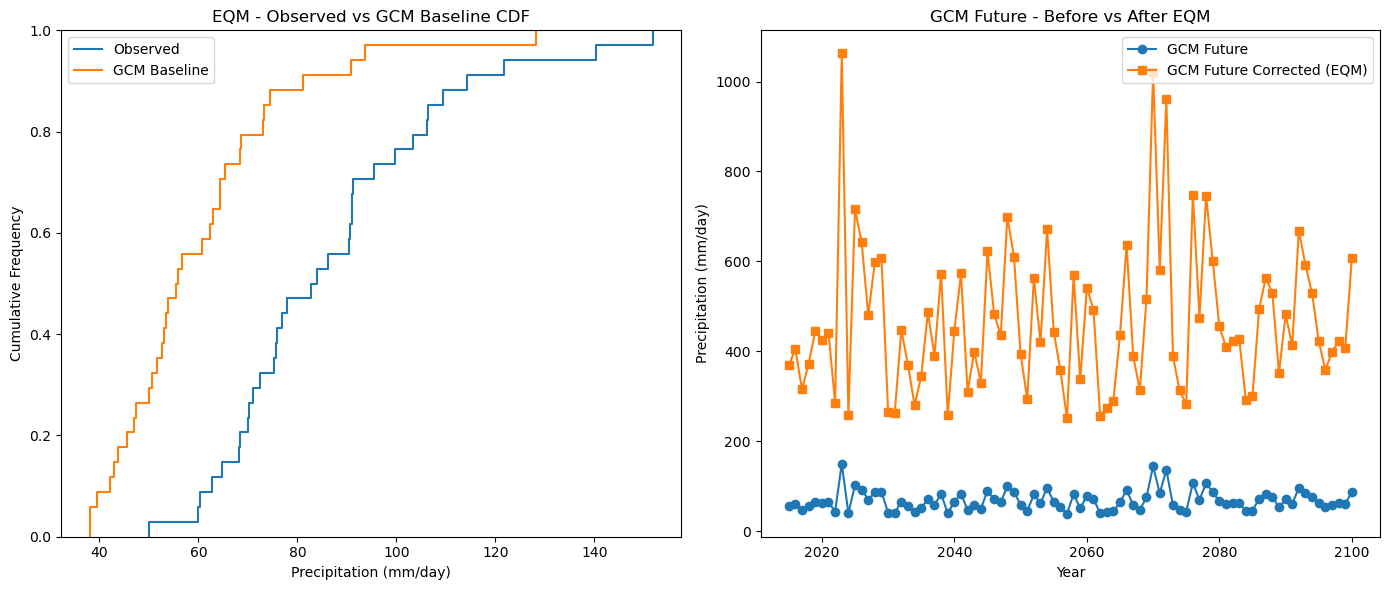

In [5]:
from idf_analysis.analysis.projection.eqm import eqm_downscaling
from idf_analysis.analysis.historical.intervals import DisaggregationScenario
import warnings
warnings.filterwarnings('ignore')

fig, axes = eqm_downscaling(
    name_obs='inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante', 
    name_baseline='CABra467/historical/1980-2013', 
    name_future='CABra467/ssp245/2015-2100', 
    dir='../results', 
    plot=True
    )

fig.show()